In [27]:
import numpy as np
import pandas as pd
from matplotlib.colors import Normalize
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.interpolate import griddata

In [25]:
bsse_data_nwchem = pd.read_csv('BSSE_by_FF_distance_nwchem.csv')

/var/folders/v1/k9l8hql13n1gcrjl_yh_gs5m0000gn/T/ipykernel_52920/3597451056.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


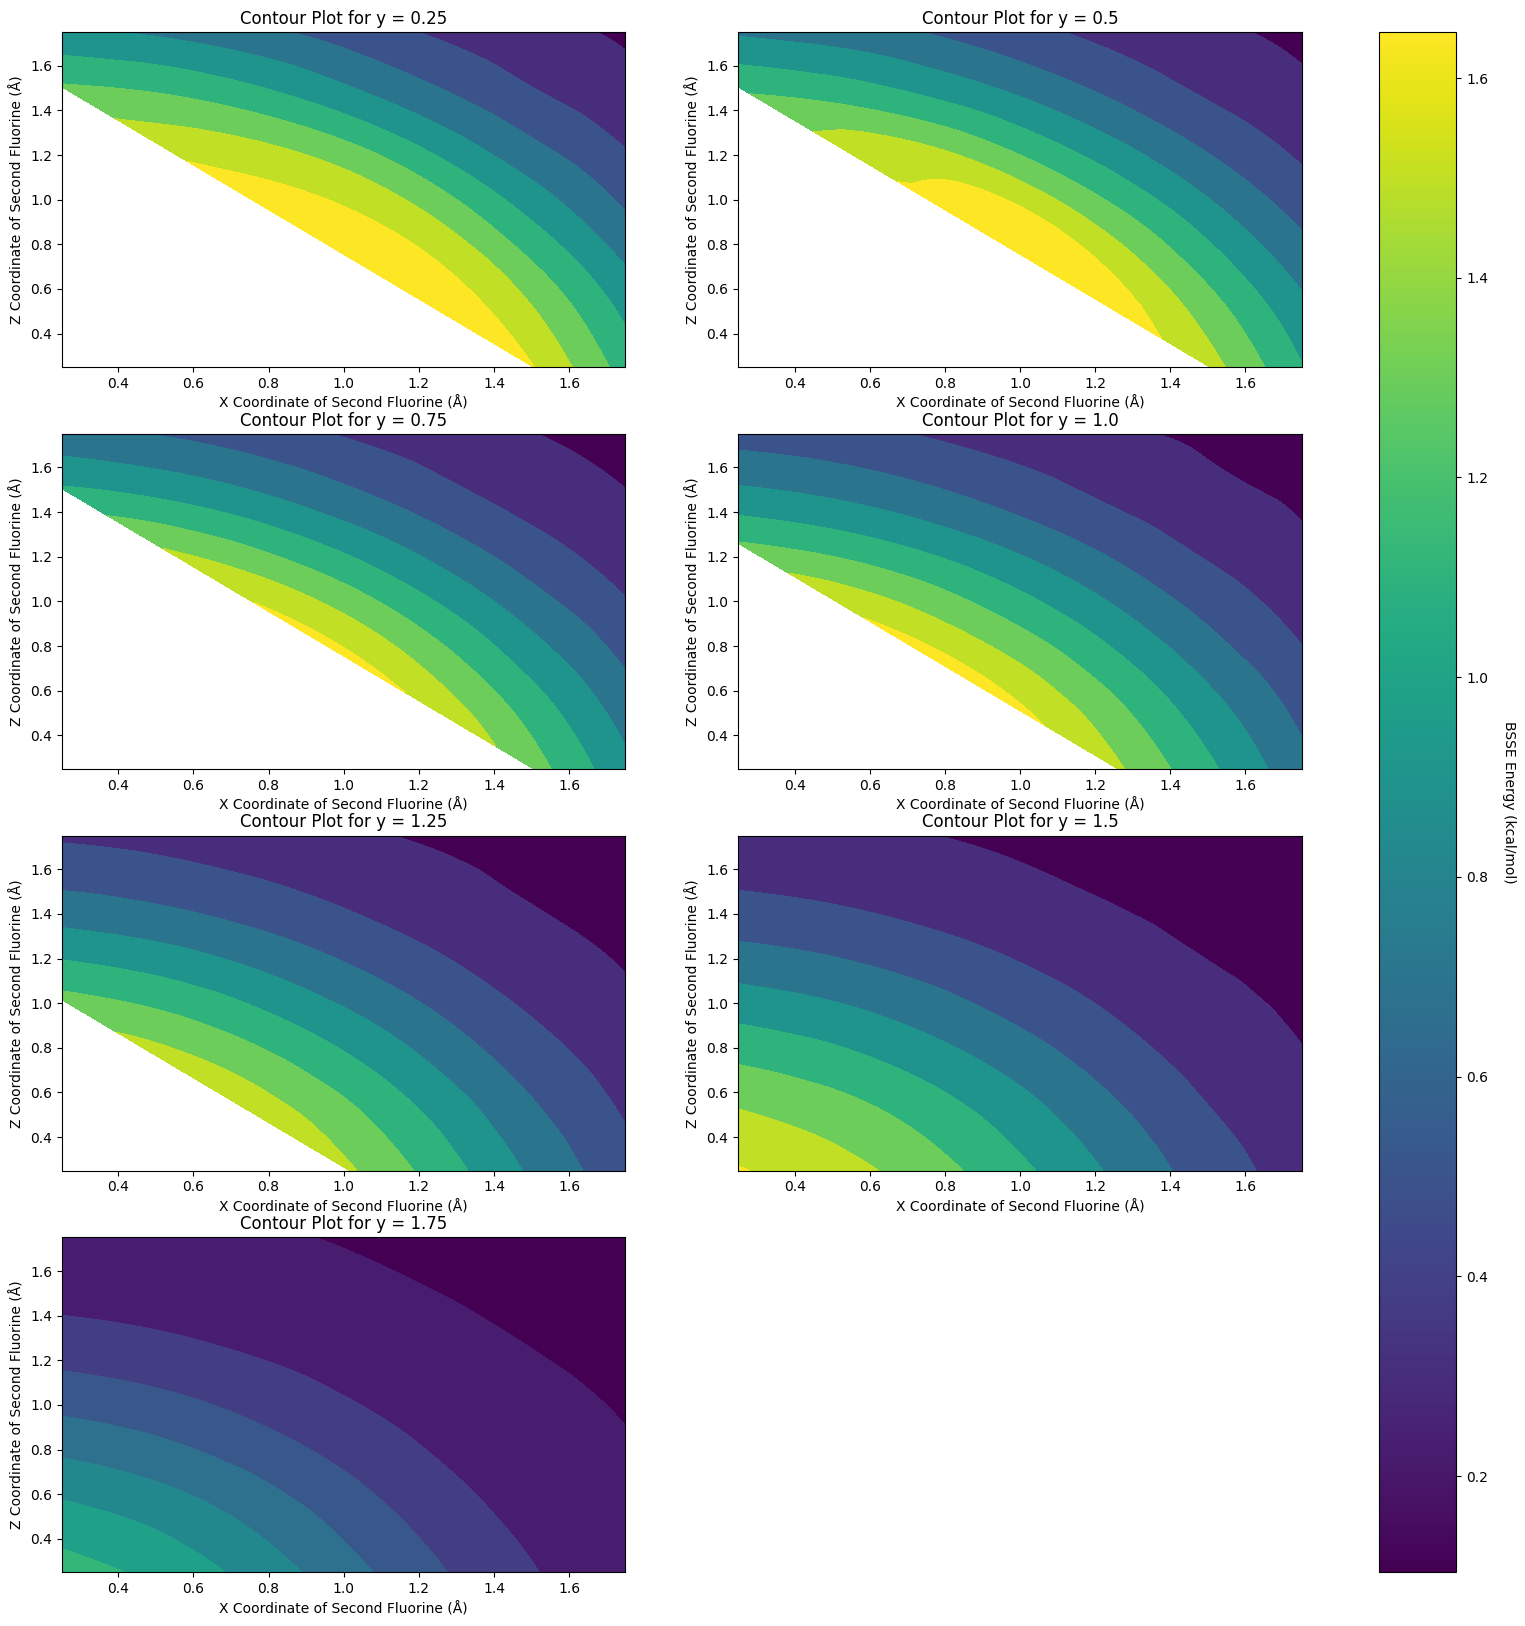

In [37]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(20, 20))
cmap = cm.get_cmap('viridis')
vmin = bsse_data_nwchem['BSSE_A'].min() * 627.5096
vmax = bsse_data_nwchem['BSSE_A'].max() * 627.5096
normalizer = Normalize(vmin=vmin, vmax=vmax)
fig.delaxes(axes[3][1])

for i, fixed_y_value in enumerate(np.arange(.25, 2, .25)):
    ax = axes[i // 2, i % 2]
    data = bsse_data_nwchem[bsse_data_nwchem['y'] == fixed_y_value][['x', 'z', 'BSSE_A']]
    xs = data['x'].values
    zs = data['z'].values
    bsse = data['BSSE_A'].values * 627.5096
    
    # Grid and interpolation
    xi = np.linspace(min(xs), max(xs), 50)
    zi = np.linspace(min(zs), max(zs), 50)
    Xi, Zi = np.meshgrid(xi, zi)
    bssei = griddata((xs, zs), bsse, (Xi, Zi), method='cubic')
    
    # Filled contour plot with fixed vmin/vmax
    contour = ax.contourf(Xi, Zi, bssei, levels=8, cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title(f'Contour Plot for y = {fixed_y_value}')
    ax.set_xlabel('X Coordinate of Second Fluorine (Å)')
    ax.set_ylabel('Z Coordinate of Second Fluorine (Å)')

# Create colorbar using the normalizer and colormap directly
cbar = fig.colorbar(cm.ScalarMappable(norm=normalizer, cmap=cmap), ax=axes.ravel().tolist())
cbar.set_label('BSSE Energy (kcal/mol)', rotation=270, labelpad=20)

plt.show()

## Fitting BSSE with a Gaussian

In [7]:
def is_pos_def(x):
    return np.all(np.linalg.eigvals(x) >= 0)

In [14]:
from scipy.optimize import curve_fit
from scipy.stats import multivariate_normal
def gauss(xyz, *p):
    A, mu_x, mu_y, mu_z, sigma_x, sigma_y, sigma_z, cov_xy, cov_xz, cov_yz = p
    # Force symmetry
    cov = np.array([[sigma_x**2, cov_xy, cov_xz],
     [cov_xy, sigma_y**2, cov_yz],
      [cov_xz, cov_yz, sigma_z**2]])
    # Ensure covariance is PSD
    if is_pos_def(cov):
        rv = multivariate_normal(mean=[mu_x, mu_y, mu_z], cov=cov)
        return A * rv.pdf(xyz)
    else:
        # Penalize invalid parameters
        return np.full(xyz.shape[0], np.inf)
p0 = [1, 0, 0, 0, 1, 1, 1, 0, 0, 0]
coords = bsse_data_nwchem[['x', 'y', 'z']].values
bsses = bsse_data_nwchem['BSSE_A'].values * 627.5096
coeff, var_matrix = curve_fit(gauss, coords, bsses, p0=p0)

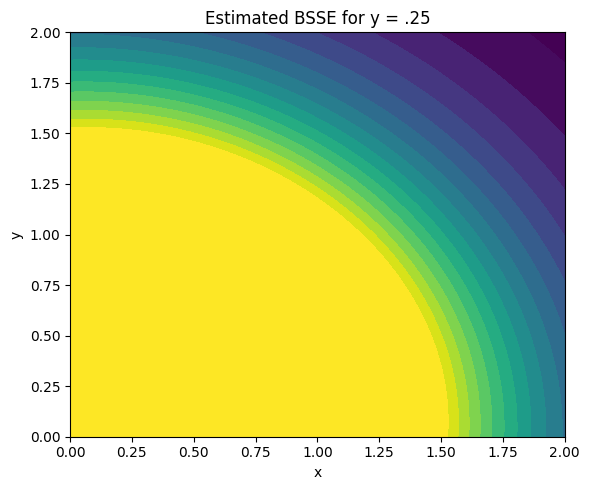

In [41]:
import numpy as np
import matplotlib.pyplot as plt
x = np.linspace(0, 2, 200)
z = np.linspace(0, 2, 200)
X, Z = np.meshgrid(x, z)
grid_points = np.column_stack([X.ravel(), Z.ravel(), .25 * np.ones_like(X.ravel())])
Z = gauss(grid_points, *coeff)
Z = Z.reshape(X.shape)
plt.figure(figsize=(6, 5))
contour = plt.contourf(X, Y, Z, levels=50, cmap='viridis', vmin=vmin, vmax=vmax)
plt.title("Estimated BSSE for y = .25")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()


/var/folders/v1/k9l8hql13n1gcrjl_yh_gs5m0000gn/T/ipykernel_52920/365371815.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


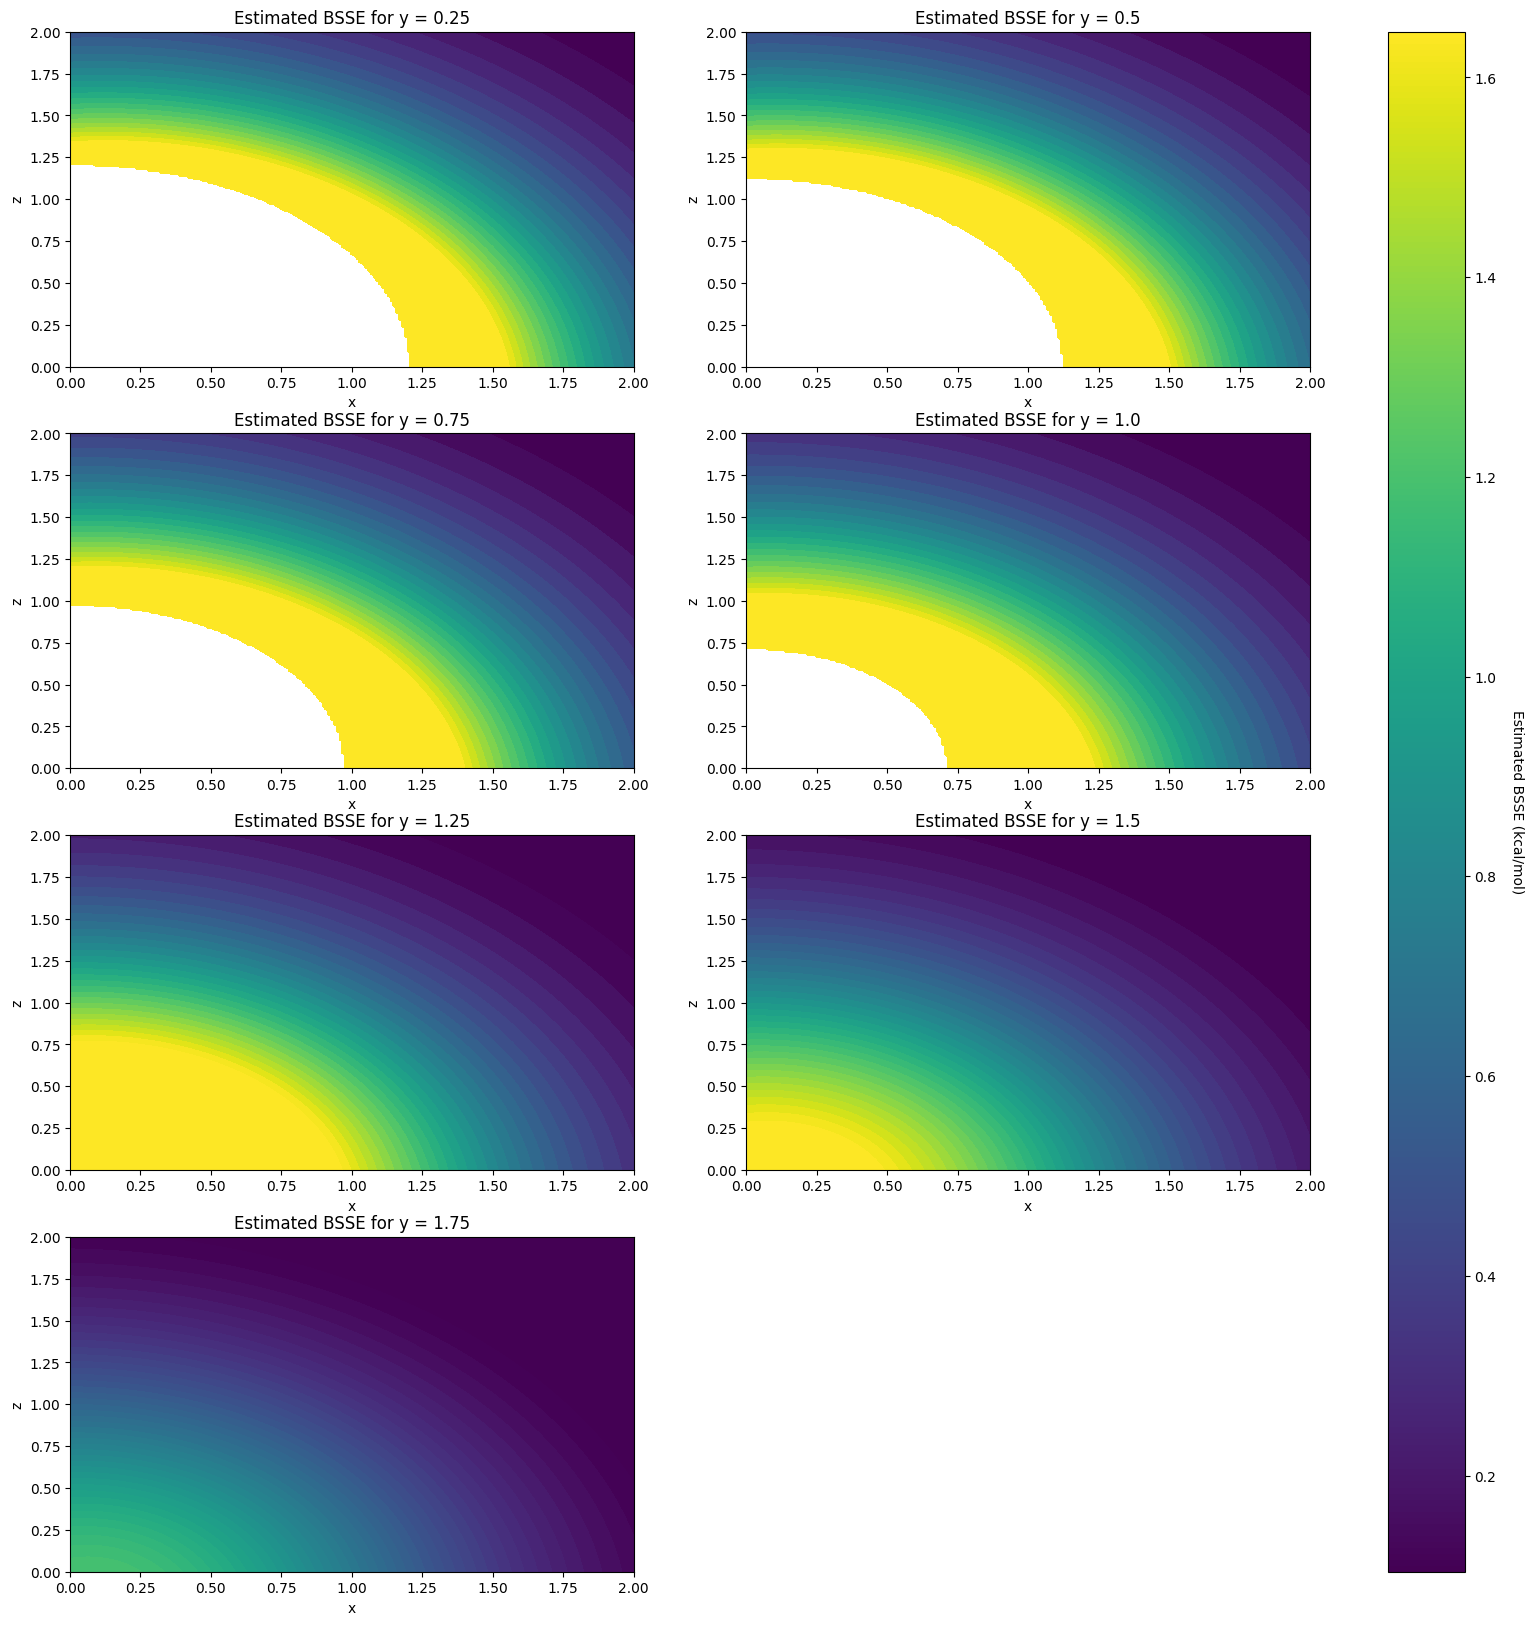

In [54]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(20, 20))
cmap = cm.get_cmap('viridis')
vmin = bsse_data_nwchem['BSSE_A'].min() * 627.5096
vmax = bsse_data_nwchem['BSSE_A'].max() * 627.5096
normalizer = Normalize(vmin=vmin, vmax=vmax)
fig.delaxes(axes[3][1])

for i, fixed_y_value in enumerate(np.arange(.25, 2, .25)):
    ax = axes[i // 2, i % 2]
    x = np.linspace(0, 2, 200)
    z = np.linspace(0, 2, 200)
    X, Z = np.meshgrid(x, z)
    grid_points = np.column_stack([X.ravel(), fixed_y_value * np.ones_like(X.ravel()), Z.ravel()])
    Z_values = gauss(grid_points, *coeff)
    Z_reshaped = Z_values.reshape(X.shape)
    mask = X**2 + fixed_y_value**2 + Z**2 < 1.5
    Z_masked = np.where(mask, np.nan, Z_reshaped)
    contour = ax.contourf(X, Z, Z_masked, levels=50, cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title(f"Estimated BSSE for y = {fixed_y_value}")
    ax.set_xlabel("x")
    ax.set_ylabel("z")

cbar = fig.colorbar(cm.ScalarMappable(norm=normalizer, cmap=cmap), ax=axes.ravel().tolist())
cbar.set_label('Estimated BSSE (kcal/mol)', rotation=270, labelpad=20)
plt.show()

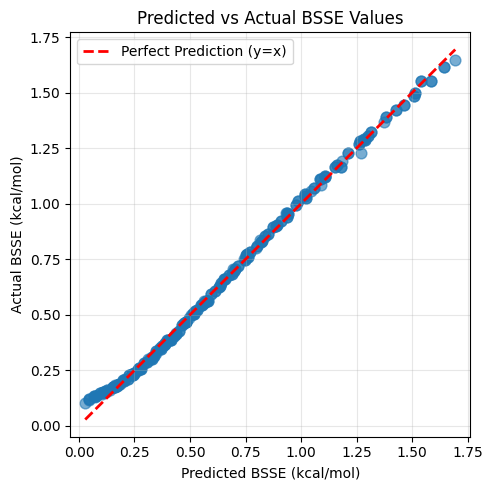

In [63]:
predicted_bsses = gauss(bsse_data_nwchem[['x', 'y', 'z']].values, *coeff)
actual_bsse = bsse_data_nwchem['BSSE_A'].values * 627.5096
bsse_data_nwchem['predicted_bsse'] = predicted_bsses
plt.figure(figsize=(5,5))
plt.scatter(predicted_bsses, actual_bsse, alpha=0.6, s=60)

# Add y=x line (perfect prediction line)
min_val = min(predicted_bsses.min(), actual_bsse.min())
max_val = max(predicted_bsses.max(), actual_bsse.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction (y=x)')

plt.xlabel('Predicted BSSE (kcal/mol)')
plt.ylabel('Actual BSSE (kcal/mol)')
plt.title('Predicted vs Actual BSSE Values')
plt.legend()
plt.grid(True, alpha=0.3)

# Make the plot square for better comparison
plt.axis('equal')
plt.tight_layout()
plt.show()

In [72]:
# show 3 decimals places

print(f"Mean Absolute Error: {np.mean(np.abs(predicted_bsses - actual_bsse)):.3f} kcal/mol")
mape = np.mean(np.abs((predicted_bsses - actual_bsse) / actual_bsse)) * 100
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f} %")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(np.mean((predicted_bsses - actual_bsse) ** 2)):.3f} kcal/mol")

Mean Absolute Error: 0.016 kcal/mol
Mean Absolute Percentage Error (MAPE): 5.75 %
Root Mean Squared Error (RMSE): 0.021 kcal/mol


In [77]:
overestimates = np.sum(predicted_bsses > actual_bsse)
underestimates = np.sum(predicted_bsses < actual_bsse)
print(f"Number of overestimates: {overestimates}")
print(f"Number of underestimates: {underestimates}")

Number of overestimates: 130
Number of underestimates: 138


/var/folders/v1/k9l8hql13n1gcrjl_yh_gs5m0000gn/T/ipykernel_52920/2962021093.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


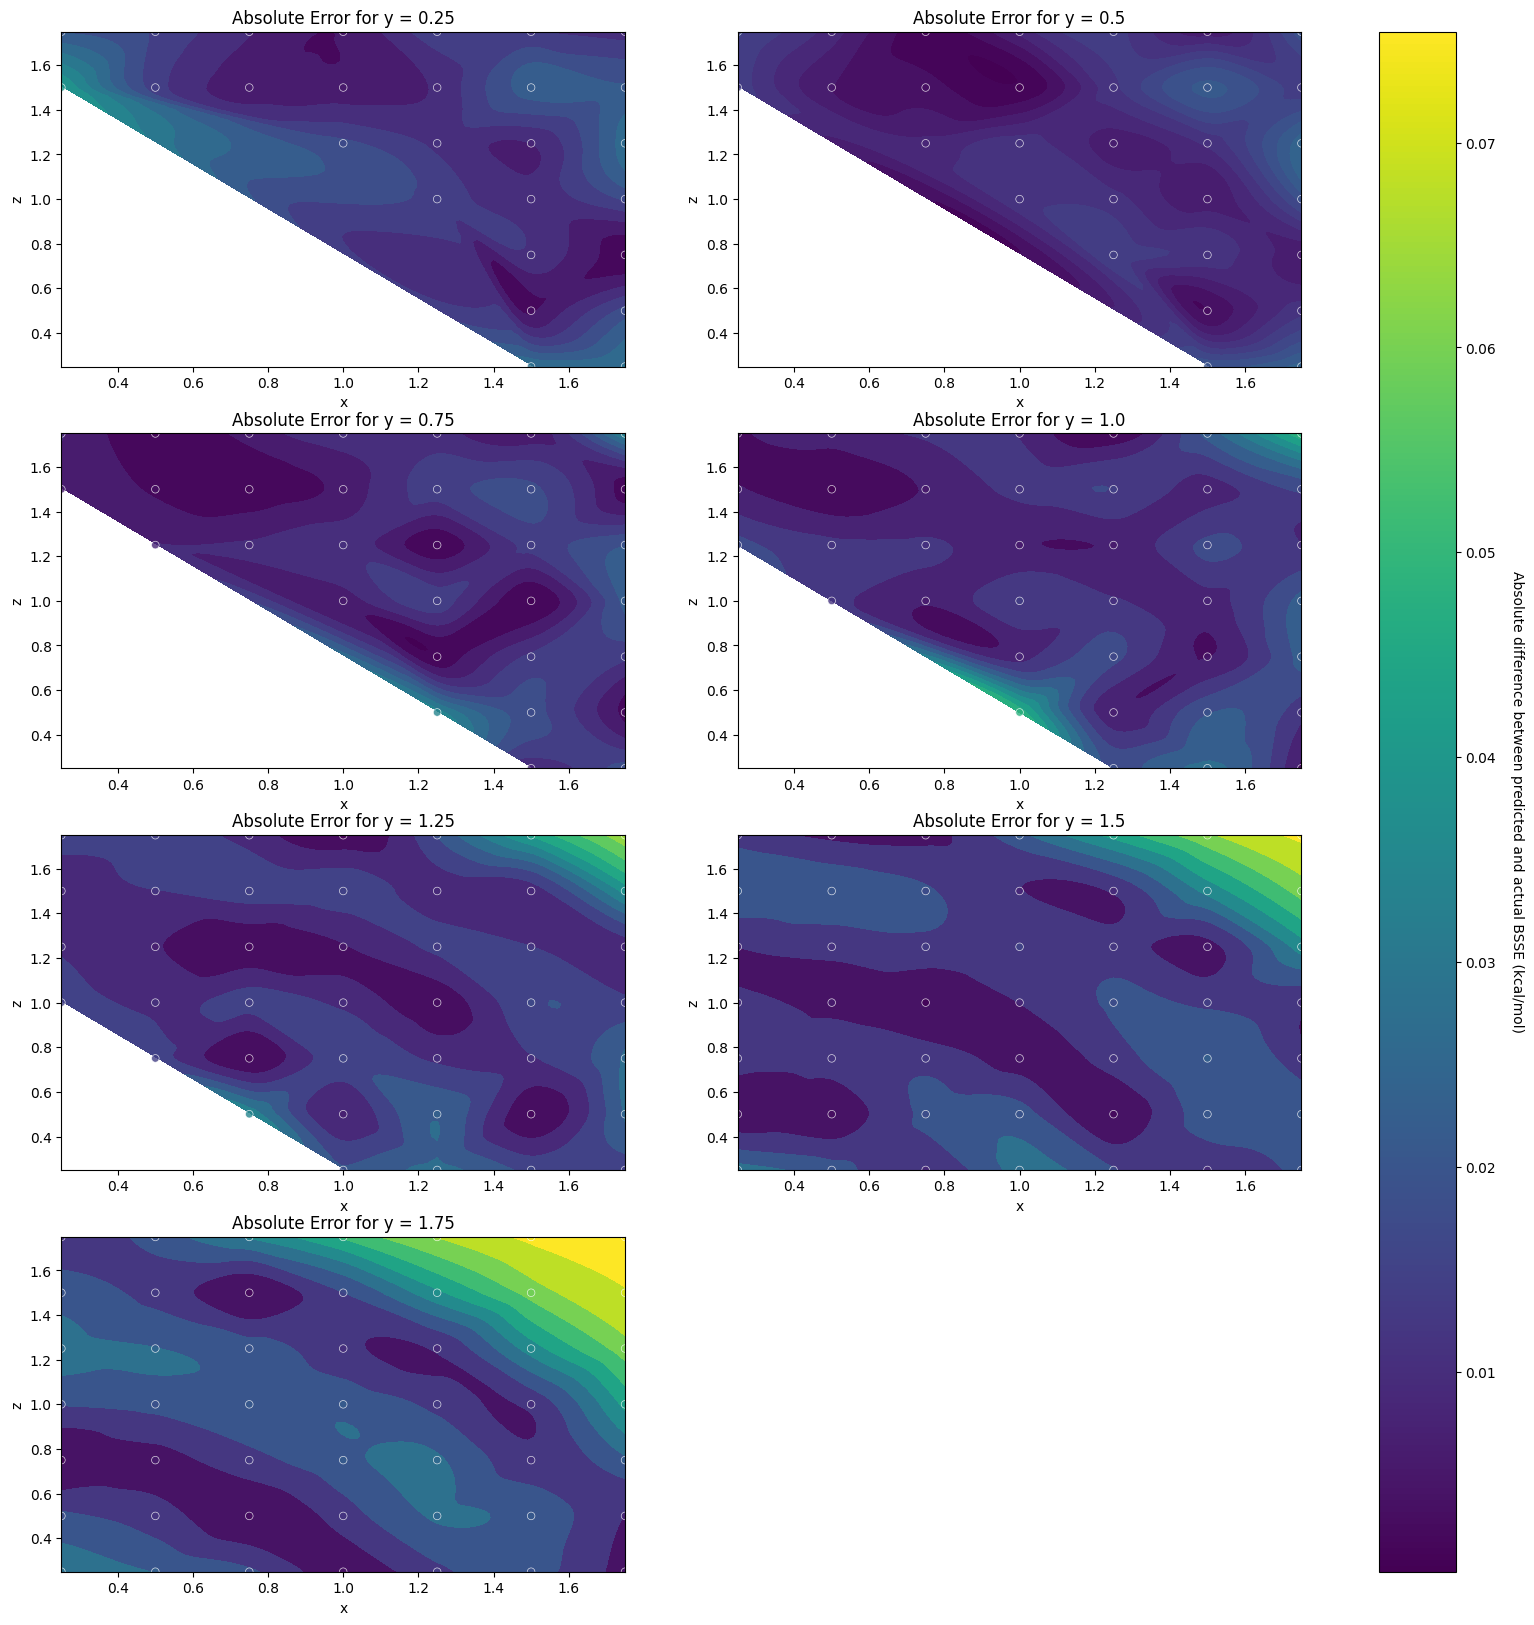

In [68]:
from scipy.interpolate import griddata

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(20, 20))
cmap = cm.get_cmap('viridis')
vmin = abs_error.min()
vmax = abs_error.max()
normalizer = Normalize(vmin=vmin, vmax=vmax)
fig.delaxes(axes[3][1])

for i, fixed_y_value in enumerate(np.arange(.25, 2, .25)):
    ax = axes[i // 2, i % 2]
    
    mask = bsse_data_nwchem['y'] == fixed_y_value
    x_data = bsse_data_nwchem[mask]['x'].values
    z_data = bsse_data_nwchem[mask]['z'].values
    error_data = abs_error[mask]
    
    x_grid = np.linspace(x_data.min(), x_data.max(), 100)
    z_grid = np.linspace(z_data.min(), z_data.max(), 100)
    X_grid, Z_grid = np.meshgrid(x_grid, z_grid)
    
    error_grid = griddata((x_data, z_data), error_data, (X_grid, Z_grid), 
                         method='cubic', fill_value=np.nan)
    
    contour = ax.contourf(X_grid, Z_grid, error_grid, levels=10, 
                         cmap=cmap, vmin=vmin, vmax=vmax)
    
    ax.scatter(x_data, z_data, c=error_data, cmap=cmap, 
              vmin=vmin, vmax=vmax, s=30, edgecolors='white', 
              linewidth=0.5, alpha=0.8)
    
    ax.set_title(f"Absolute Error for y = {fixed_y_value}")
    ax.set_xlabel("x")
    ax.set_ylabel("z")

cbar = fig.colorbar(cm.ScalarMappable(norm=normalizer, cmap=cmap), ax=axes.ravel().tolist())
cbar.set_label('Absolute difference between predicted and actual BSSE (kcal/mol)', rotation=270, labelpad=20)
plt.show()